In [2]:
import numpy as np
import pandas as pd
import pickle
import deepchem as dc
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import rdMolDescriptors 
from rdkit.Chem import Draw
from rdkit.Chem import Descriptors
from rdkit import DataStructs
import selfies as sf
from statistics import mean
from statistics import stdev
import tensorflow as tf
from tensorflow.python.eager import polymorphic_function
polymorphic_function.reduce_retracing = True

# Check versions of DeepChem and RDKit
dc_version = dc.__version__
rk_version = Chem.rdBase.rdkitVersion
print(f"DeepChem version: {dc_version}, RDKit version: {rk_version}")

# Suppress DeepChem warnings regarding missing dependencies
import warnings
warnings.filterwarnings("ignore", message="Skipped loading modules with pytorch-geometric dependency")
warnings.filterwarnings("ignore", message="Skipped loading modules with pytorch-lightning dependency")
warnings.filterwarnings("ignore", message="Skipped loading some Jax models")

DeepChem version: 2.8.0, RDKit version: 2022.09.5


In [3]:
ms = pd.read_pickle(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1249_CHOSi\_aromatic_2025_1249_CHOSi.pkl")
ms

,Name,Form,Mw,Cas,mz1,mz2,mz3,mz4,mz5,mz6,...,mz594,mz595,mz596,mz597,mz598,mz599,mz600,Filter_Form,SMILES,AtomGroup
235,1-Diphenylmethylsilyloxy-2-methylhexan-5-ol-3-one,C20H26O3Si,342,NaN,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,CC(O)CC(=O)C(C)CO[Si](C)(c1ccccc1)c2ccccc2,CHOSi
1287,1-Phenyl-2-triisopropylsilyloxy-propene,C18H30OSi,290,NaN,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,CC(C)[Si](OC(C)=Cc1ccccc1)(C(C)C)C(C)C,CHOSi
9851,"Silane, trimethyl[(7-phenoxyheptyl)oxy]-",C16H28O2Si,280,16654-57-2,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,C[Si](C)(C)OCCCCCCCOc1ccccc1,CHOSi
10183,"Silane, trimethyl[(6-phenoxyhexyl)oxy]-",C15H26O2Si,266,16654-55-0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,C[Si](C)(C)OCCCCCCOc1ccccc1,CHOSi
11241,1-Methoxy- 5-trimethylsilyloxy-3-phenylpentane,C15H26O2Si,266,NaN,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,COCCC(CCO[Si](C)(C)C)c1ccccc1,CHOSi
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
165443,"3,3,5,5,9,9,11,11-Octamethyl-1,7-diphenylbicyc...",C20H34O7Si6,554,49538-51-4,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,C[Si]1(C)O[Si](C)(C)O[Si]2(O[Si](C)(C)O[Si](C)...,CHOSi
165731,1-Diphenylmethylsilyloxy-2-methylhexan-5-ol-3-one,C20H26O3Si,342,NaN,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,CC(O)CC(=O)C(C)CO[Si](C)(c1ccccc1)c2ccccc2,CHOSi
166783,1-Phenyl-2-triisopropylsilyloxy-propene,C18H30OSi,290,NaN,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,CC(C)[Si](OC(C)=Cc1ccccc1)(C(C)C)C(C)C,CHOSi
174241,1-Diphenylmethylsilyloxy-2-methylhexan-5-ol-3-one,C20H26O3Si,342,NaN,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,CC(O)CC(=O)C(C)CO[Si](C)(c1ccccc1)c2ccccc2,CHOSi


In [ ]:
import deepchem as dc
import selfies as sf
import pandas as pd
X = ms.iloc[:, 4:604]     # spectra
y = ms.iloc[:, 605]       # smiles

se = []
dr = []  # list of indices to drop
c = 0

# Check all SMILES and filter out invalid/unsupported ones
for i in y:
    try:
        selfies_str = sf.encoder(i)
        se.append(selfies_str)
        if '.' in selfies_str:  # check for multi-molecule SMILES
            dr.append(c)
    except Exception as e:
        # Add to drop list if encoding fails (chemically invalid SMILES)
        dr.append(c)
    c += 1

# Drop problematic rows from original DataFrame
ms_cleaned = ms.drop(index=ms.index[dr]).reset_index(drop=True)

# Extract cleaned spectra and SMILES
X_clean = ms_cleaned.iloc[:, 4:604].to_numpy()
y_clean = ms_cleaned.iloc[:, 605].to_numpy()

# Create DeepChem dataset
ds = dc.data.DiskDataset.from_numpy(X_clean, y_clean)
ds

<DiskDataset X.shape: (np.int64(1249), np.int64(600)), y.shape: (np.int64(1249),), w.shape: (np.int64(1249),), task_names: [0]>

In [5]:
# Make a dictionary of all 'SELFIES' parts in the dataset

dataset = se
alphabet = sf.get_alphabet_from_selfies(dataset)
alphabet.add('[nop]')  # '[nop]' is a special padding symbol
alphabet = list(sorted(alphabet))
pad_to_len = max(sf.len_selfies(s) for s in dataset)
symbol_to_idx = {s: i for i, s in enumerate(alphabet)}
symbol_to_idx

{'[#Branch1]': 0,
 '[#Branch2]': 1,
 '[#C]': 2,
 '[/C]': 3,
 '[/Si]': 4,
 '[=Branch1]': 5,
 '[=Branch2]': 6,
 '[=CH0]': 7,
 '[=CH2]': 8,
 '[=C]': 9,
 '[=N]': 10,
 '[=O]': 11,
 '[=Ring1]': 12,
 '[=Ring2]': 13,
 '[Branch1]': 14,
 '[Branch2]': 15,
 '[C@@H1]': 16,
 '[C@@]': 17,
 '[C@H1]': 18,
 '[C@]': 19,
 '[CH0]': 20,
 '[C]': 21,
 '[N]': 22,
 '[O]': 23,
 '[P]': 24,
 '[Ring1]': 25,
 '[Ring2]': 26,
 '[S]': 27,
 '[SiH1]': 28,
 '[SiH2]': 29,
 '[SiH3]': 30,
 '[Si]': 31,
 '[\\C]': 32,
 '[\\O]': 33,
 '[nop]': 34}

In [6]:
# Convert all SELFIES to ONE-HOT-FLAT (one-hot-flat can be used for machine learning)
sf_hot = sf.batch_selfies_to_flat_hot(se, vocab_stoi=symbol_to_idx, pad_to_len=pad_to_len)
# Create deepchem dataset X=spectrum y=SELFIES one-hot-flat
dataset = dc.data.NumpyDataset(X=np.array(ds.X, dtype='float'), y=sf_hot)

In [8]:
import deepchem as dc

seed = 123  
splitter = dc.splits.RandomStratifiedSplitter()

train_dataset, valid_dataset, test_dataset = splitter.train_valid_test_split(
    dataset=dataset,
    frac_train=0.9,
    frac_valid=0,
    frac_test=0.1,
    seed=seed
)

print(f"🔹 Seed used: {seed}")
print(f"📦 Training set size: {len(train_dataset)}")
print(f"📦 Validation set size: {len(valid_dataset)}")
print(f"📦 Test set size: {len(test_dataset)}")


🔹 Seed used: 123
📦 Training set size: 1089
📦 Validation set size: 0
📦 Test set size: 160


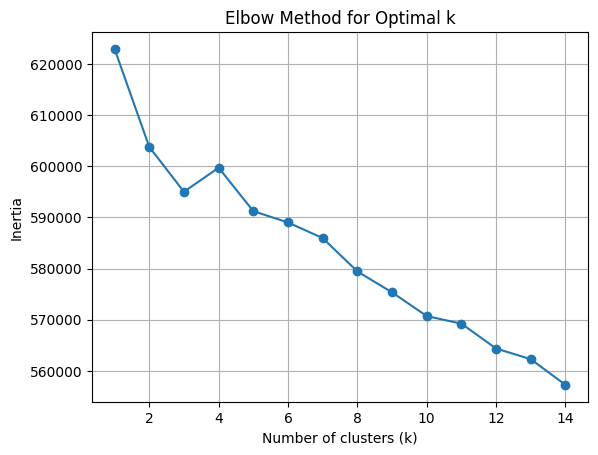

🔍 Elbow point detected at k = 3


In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from kneed import KneeLocator 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(train_dataset.X)
inertias = []
k_range = range(1, 15)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X_train_scaled)
    inertias.append(kmeans.inertia_)
plt.plot(k_range, inertias, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.grid(True)
plt.show()
kl = KneeLocator(k_range, inertias, curve='convex', direction='decreasing')
print(f"🔍 Elbow point detected at k = {kl.elbow}")

In [10]:
import os
import pickle
import numpy as np
from sklearn.cluster import KMeans

def train_and_save_kmeans_clusters(X_train, n_clusters=3,
                                   model_dir=r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1249_CHOSi\Splitting  with seed 123\kmeans_model",
                                   cluster_dir=r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1249_CHOSi\Splitting  with  seed 123\clustering_from_trainset"):
    """
    Train KMeans on the training data, save the model, cluster data, and sample indices.

    Parameters:
    - X_train (np.ndarray): Training features
    - n_clusters (int): Number of clusters
    - model_dir (str): Path to save the KMeans model
    - cluster_dir (str): Path to save each cluster's data and indices

    Returns:
    - kmeans (KMeans): Trained model
    - cluster_files (dict): cluster_id -> file path for data and indices
    """
    os.makedirs(model_dir, exist_ok=True)
    os.makedirs(cluster_dir, exist_ok=True)

    # Train KMeans
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    labels = kmeans.fit_predict(X_train)

    # Save model
    model_path = os.path.join(model_dir, "kmeans_model.pkl")
    with open(model_path, "wb") as f:
        pickle.dump(kmeans, f)
    print(f"✅ KMeans model saved to: {model_path}")

    # Save each cluster's data and indices
    cluster_files = {}
    for cluster_id in range(n_clusters):
        indices = np.where(labels == cluster_id)[0]
        cluster_data = X_train[indices]

        data_path = os.path.join(cluster_dir, f"cluster_{cluster_id}.pkl")
        idx_path = os.path.join(cluster_dir, f"cluster_{cluster_id}_indices.npy")

        with open(data_path, "wb") as f:
            pickle.dump(cluster_data, f)
        np.save(idx_path, indices)

        cluster_files[cluster_id] = {
            "data_path": data_path,
            "indices_path": idx_path
        }

        print(f"📁 Cluster {cluster_id} saved: {data_path}")
        print(f"📌 Indices saved: {idx_path}")

    return kmeans, cluster_files
kmeans_model, cluster_paths = train_and_save_kmeans_clusters(train_dataset.X, n_clusters=3)


✅ KMeans model saved to: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1249_CHOSi\Splitting  with seed 123\kmeans_model\kmeans_model.pkl
📁 Cluster 0 saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1249_CHOSi\Splitting  with  seed 123\clustering_from_trainset\cluster_0.pkl
📌 Indices saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1249_CHOSi\Splitting  with  seed 123\clustering_from_trainset\cluster_0_indices.npy
📁 Cluster 1 saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1249_CHOSi\Splitting  with  seed 123\clustering_from_trainset\cluster_1.pkl
📌 Indices saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splittin

In [11]:
import pickle

cluster_dir = r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1249_CHOSi\Splitting  with  seed 123\clustering_from_trainset"
clusters = {}

for i in range(3):
    path = f"{cluster_dir}/cluster_{i}.pkl"
    with open(path, "rb") as f:
        clusters[i] = pickle.load(f)

for i in clusters:
    print(f"Cluster {i} shape: {clusters[i].shape}")



Cluster 0 shape: (170, 600)
Cluster 1 shape: (706, 600)
Cluster 2 shape: (213, 600)


✅ KMeans model saved to: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1249_CHOSi\Splitting  with seed 123\kmeans_model\kmeans_model.pkl
📁 Cluster 0 saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1249_CHOSi\Splitting  with  seed 123\clustering_from_trainset\cluster_0.pkl
📌 Indices saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1249_CHOSi\Splitting  with  seed 123\clustering_from_trainset\cluster_0_indices.npy
📁 Cluster 1 saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1249_CHOSi\Splitting  with  seed 123\clustering_from_trainset\cluster_1.pkl
📌 Indices saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splittin

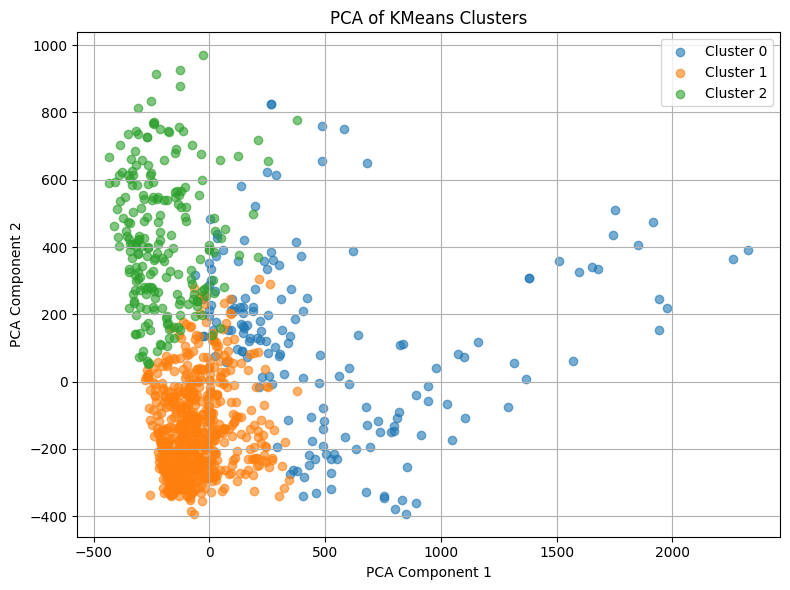

In [12]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def plot_clusters_pca(X, labels, title="PCA of KMeans Clusters"):
    """
    Plots clustered instances using PCA to reduce to 2D.

    Parameters:
    - X (np.ndarray): The input data (e.g., from train_dataset.X)
    - labels (np.ndarray): Cluster labels assigned by KMeans
    - title (str): Title for the plot
    """
    # Perform PCA
    pca = PCA(n_components=2)
    reduced = pca.fit_transform(X)

    # Plot clusters
    plt.figure(figsize=(8, 6))
    unique_labels = np.unique(labels)
    for cluster_id in unique_labels:
        idx = labels == cluster_id
        plt.scatter(reduced[idx, 0], reduced[idx, 1], label=f"Cluster {cluster_id}", alpha=0.6)

    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
kmeans_model, _ = train_and_save_kmeans_clusters(train_dataset.X, n_clusters=3)
labels = kmeans_model.predict(train_dataset.X)

# Plot clusters
plot_clusters_pca(train_dataset.X, labels)


In [13]:
import pickle
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1249_CHOSi\Splitting  with seed 123\kmeans_model\kmeans_model.pkl", "rb") as f:
    kmeans_model = pickle.load(f)

In [ ]:


import os
import pickle
import numpy as np

def assign_and_save_clusters(X, kmeans_model, output_dir=r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1249_CHOSi\Splitting  with  Splitting  with seed 123\clustering_from_testset", dataset_label="test"):
    """
    Applies a trained KMeans model to a new dataset (e.g., test or validation),
    saves each cluster's data and sample indices.

    Parameters:
    - X (np.ndarray): Feature matrix (e.g., test_dataset.X)
    - kmeans_model (KMeans): Trained KMeans model
    - output_dir (str): Directory to save clustered data
    - dataset_label (str): Label for logging (e.g., "test" or "valid")
    """
    os.makedirs(output_dir, exist_ok=True)

    # Predict cluster labels
    cluster_labels = kmeans_model.predict(X)

    # For each cluster, save data and indices
    for cluster_id in np.unique(cluster_labels):
        indices = np.where(cluster_labels == cluster_id)[0]
        cluster_data = X[indices]

        # Save cluster data
        data_path = os.path.join(output_dir, f"cluster_{cluster_id}.pkl")
        with open(data_path, "wb") as f:
            pickle.dump(cluster_data, f)

        # Save indices
        idx_path = os.path.join(output_dir, f"cluster_{cluster_id}_indices.npy")
        np.save(idx_path, indices)

        print(f"✅ Saved {dataset_label} cluster {cluster_id} to: {data_path}")
        print(f"📌 Indices saved to: {idx_path}")

    return cluster_labels
test_X = test_dataset.X 
test_clusters = assign_and_save_clusters(test_X, kmeans_model, output_dir=r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1249_CHOSi\Splitting  with  Splitting  with seed 123\clustering_from_testset", dataset_label="test")

✅ Saved test cluster 0 to: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1249_CHOSi\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_0.pkl
📌 Indices saved to: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1249_CHOSi\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_0_indices.npy
✅ Saved test cluster 1 to: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1249_CHOSi\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_1.pkl
📌 Indices saved to: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1249_CHOSi\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_1_in

Cluster 0: size = 25, shape = (25, 600)
Cluster 1: size = 98, shape = (98, 600)
Cluster 2: size = 37, shape = (37, 600)


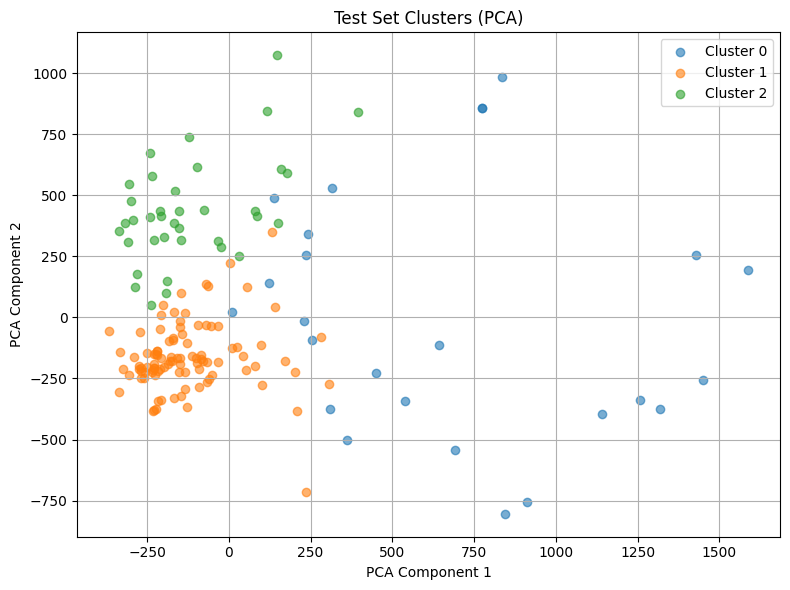

In [15]:

import pickle
import os

Test_dir = r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1249_CHOSi\Splitting  with  Splitting  with seed 123\clustering_from_testset"
Test_clusters = {}

# Load clusters from pickle files
for i in range(3):  
    path = os.path.join(Test_dir, f"cluster_{i}.pkl")
    with open(path, "rb") as f:
        Test_clusters[i] = pickle.load(f)

# Print the size and shape of each cluster
for cluster_id, data in Test_clusters.items():
    print(f"Cluster {cluster_id}: size = {len(data)}, shape = {data.shape}")


plot_clusters_pca(test_X, test_clusters, title="Test Set Clusters (PCA)")


Epoch 1/100 - Loss: 1.261274
Epoch 2/100 - Loss: 0.075596
Epoch 3/100 - Loss: 0.063083
Epoch 4/100 - Loss: 0.047981
Epoch 5/100 - Loss: 0.039356
Epoch 6/100 - Loss: 0.036849
Epoch 7/100 - Loss: 0.035159
Epoch 8/100 - Loss: 0.033619
Epoch 9/100 - Loss: 0.032408
Epoch 10/100 - Loss: 0.031200
Epoch 11/100 - Loss: 0.030178
Epoch 12/100 - Loss: 0.029204
Epoch 13/100 - Loss: 0.028077
Epoch 14/100 - Loss: 0.027029
Epoch 15/100 - Loss: 0.026048
Epoch 16/100 - Loss: 0.025063
Epoch 17/100 - Loss: 0.024153
Epoch 18/100 - Loss: 0.023043
Epoch 19/100 - Loss: 0.022065
Epoch 20/100 - Loss: 0.020831
Epoch 21/100 - Loss: 0.019995
Epoch 22/100 - Loss: 0.018884
Epoch 23/100 - Loss: 0.018086
Epoch 24/100 - Loss: 0.017174
Epoch 25/100 - Loss: 0.016264
Epoch 26/100 - Loss: 0.015565
Epoch 27/100 - Loss: 0.014632
Epoch 28/100 - Loss: 0.013677
Epoch 29/100 - Loss: 0.012425
Epoch 30/100 - Loss: 0.012264
Epoch 31/100 - Loss: 0.011810
Epoch 32/100 - Loss: 0.010972
Epoch 33/100 - Loss: 0.010118
Epoch 34/100 - Loss

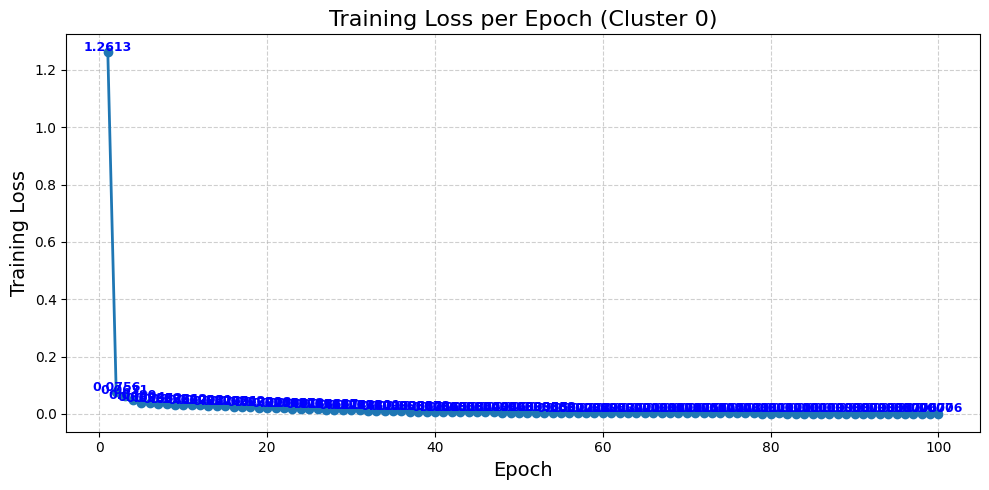

✅ Training complete. Model, loss plot, and architecture saved to:
C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1249_CHOSi\Splitting  with  seed 123\models_\model0000


In [16]:
import os
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt
import deepchem as dc

# === Load training cluster 0 data
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1249_CHOSi\Splitting  with  seed 123\clustering_from_trainset\cluster_0.pkl", "rb") as f:
    X_cluster0 = pickle.load(f)

cluster_0_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1249_CHOSi\Splitting  with  seed 123\clustering_from_trainset\cluster_0_indices.npy")
y_cluster0 = train_dataset.y[cluster_0_indices]

# Ensure y is 2D
if len(y_cluster0.shape) == 1:
    y_cluster0 = y_cluster0.reshape(-1, 1)

# === Create DeepChem dataset
train_dataset_0 = dc.data.NumpyDataset(X=np.array(X_cluster0), y=np.array(y_cluster0))

# === Model config
n_tasks = train_dataset_0.y.shape[1]
n_features = train_dataset_0.X.shape[1]
layer_sizes = [1000, 1000, 1000]
dropout_rate = 0.1
num_epochs = 100

model_0 = dc.models.MultitaskClassifier(
    n_tasks=n_tasks,
    n_features=n_features,
    layer_sizes=layer_sizes,
    dropouts=dropout_rate
)

# === Output directory
model_dir = r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1249_CHOSi\Splitting  with  seed 123\models_\model0000"
os.makedirs(model_dir, exist_ok=True)

# === Training
losses = []

for epoch in range(num_epochs):
    loss = model_0.fit(train_dataset_0, nb_epoch=1)
    losses.append(loss)
    print(f"Epoch {epoch + 1}/{num_epochs} - Loss: {loss:.6f}")

# === Plot training loss
final_plot = os.path.join(model_dir, "train_loss_plot.png")
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(losses) + 1), losses, marker='o', linewidth=2, markersize=6)
for i, l in enumerate(losses):
    plt.text(i + 1, l + 0.005, f"{l:.4f}", fontsize=9, fontweight='bold', ha='center', color='blue')

plt.title("Training Loss per Epoch (Cluster 0)", fontsize=16)
plt.xlabel("Epoch", fontsize=14)
plt.ylabel("Training Loss", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(final_plot)
plt.show()

# === Save model weights and architecture
model_0.save_checkpoint(model_dir=model_dir)

arch_dict = {
    "n_tasks": n_tasks,
    "n_features": n_features,
    "layer_sizes": layer_sizes,
    "dropout_rate": dropout_rate
}
arch_file = os.path.join(model_dir, "architecture.json")
with open(arch_file, "w") as f:
    json.dump(arch_dict, f, indent=4)

print("✅ Training complete. Model, loss plot, and architecture saved to:")
print(model_dir)


In [17]:
import pickle
import numpy as np

# === Load cluster 0 features from test set
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1249_CHOSi\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_0.pkl", "rb") as f:
    X_test_cluster0 = pickle.load(f)

# === Load corresponding indices
test_cluster_0_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1249_CHOSi\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_0_indices.npy")

# === Extract corresponding labels from the original test set
y_test_cluster0 = test_dataset.y[test_cluster_0_indices]

if len(y_test_cluster0.shape) == 1:
    y_test_cluster0 = y_test_cluster0.reshape(-1, 1)


In [18]:

import deepchem as dc
test_dataset_0 = dc.data.NumpyDataset(X=np.array(X_test_cluster0), y=np.array(y_test_cluster0))

test_dataset_0 = dc.data.NumpyDataset(X=np.array(X_test_cluster0), y=np.array(y_test_cluster0))

predictions_0 = model_0.predict(test_dataset_0)

print("✅ Prediction shape:", predictions_0.shape)
print("Example prediction:", predictions_0[0])



✅ Prediction shape: (25, 2590, 2)
Example prediction: [[1.0000000e+00 2.3919112e-16]
 [1.0000000e+00 1.3209364e-12]
 [1.0000000e+00 4.5533553e-13]
 ...
 [1.0000000e+00 1.2207726e-11]
 [1.0000000e+00 4.2377266e-15]
 [2.5259354e-14 1.0000000e+00]]


In [19]:
itos={}
c=0
for i in symbol_to_idx:
  itos[c]=i
  c=c+1
itos
from rdkit import Chem, DataStructs
import numpy as np


In [20]:

def evaluate_flat_predictions(predictions, test_dataset, itos, sf, cutoff=0.5):
    """
    Evaluate SELFIES predictions from flat one-hot output format.
    Args:
        predictions: model outputs (shape: [num_samples, sequence_len * vocab_size])
        test_dataset: DeepChem test dataset
        itos: index-to-symbol mapping (dict or list)
        sf: selfies module (with decoder)
        cutoff: threshold for class activation

    Returns:
        Prints evaluation stats and decoded examples
    """
    if isinstance(itos, list):
        itos = {i: tok for i, tok in enumerate(itos)}

    vocab_size = len(itos)
    total = len(test_dataset)
    hit = 0
    tanimoto_scores = []

    for idx in range(total):
        flat_pred = predictions[idx]
        binary_pred = [1 if val[1] >= cutoff else 0 for val in flat_pred]  

        num_tokens = len(binary_pred) // vocab_size
        selfie_str = ''
        for i in range(num_tokens):
            for j in range(vocab_size):
                if binary_pred[i * vocab_size + j] == 1 and itos[j] != '[nop]':
                    selfie_str += itos[j]

        try:
            pred_smiles = sf.decoder(selfie_str)
        except:
            pred_smiles = ''

        ground_truth_flat = test_dataset.y[idx]
        true_indices = np.argmax(ground_truth_flat.reshape(-1, vocab_size), axis=1)
        true_selfie = ''.join([itos.get(i, '') for i in true_indices])
        try:
            true_smiles = sf.decoder(true_selfie)
        except:
            true_smiles = ''

        # RDKit comparison
        mol_pred = Chem.MolFromSmiles(pred_smiles)
        mol_true = Chem.MolFromSmiles(true_smiles)
        if mol_pred is None or mol_true is None:
            tanimoto = 0.0
        else:
            fp_pred = Chem.RDKFingerprint(mol_pred)
            fp_true = Chem.RDKFingerprint(mol_true)
            tanimoto = DataStructs.FingerprintSimilarity(fp_pred, fp_true)

        tanimoto_scores.append(tanimoto)
        if pred_smiles == true_smiles:
            hit += 1

        print(f"[{idx}] Pred: {pred_smiles} | True: {true_smiles} | Tanimoto: {tanimoto:.3f}")

    # Summary
    tanimoto_scores = np.array(tanimoto_scores)
    print("\n📊 Evaluation Summary:")
    print(f"✅ Exact SMILES match: {hit}/{total} ({100*hit/total:.1f}%)")
    print(f"Tanimoto >= 1.0: {np.sum(tanimoto_scores == 1.0)}")
    print(f"Tanimoto >= 0.9: {np.sum(tanimoto_scores >= 0.9)}")
    print(f"Tanimoto >= 0.6: {np.sum(tanimoto_scores >= 0.6)}")
    print(f"Avg Tanimoto: {tanimoto_scores.mean():.3f}")


In [21]:
evaluate_flat_predictions(predictions_0, test_dataset_0, itos, sf, cutoff=0.5)


[0] Pred: CC(C)[Si](OC(C)=CC1=CC=CC=C1)(C(C)C)C(C)C | True: CC(C)[Si](OC(C)=CC1=CC=CC=C1)(C(C)C)C(C)C | Tanimoto: 1.000
[1] Pred: CC[Si](C)(C)OCCC(CCOC)C1=CC=CC=C1 | True: CC[Si](C)(C)OCCC(CCOC)C1=CC=CC=C1 | Tanimoto: 1.000
[2] Pred: CC(C)(C)CC(C)C(C1)CC=CC=C1 | True: C[Si](C)(C)OC(CCCCC(=O)OC1=CC=CC=C1)CCC2=CC=CC=C2 | Tanimoto: 0.068
[3] Pred: C[Si](CCO)CC=CC(CC=C)C=CC(=C)C=CC | True: CC1=CC=CC=C1CO[SiH1](C2=CC=CC=C2)C3=CC=CC=C3 | Tanimoto: 0.053
[4] Pred: COCCCCCCCCCC(C)C=CC=CC#C | True: CC1=CC=CC(CO[SiH2]C[Si](C)(C)C)=C1C | Tanimoto: 0.044
[5] Pred: COCCCCCCCCO[Si]CC(C)C(C1)COCCC1 | True: CC(C)(C)[Si](C)(C)OCC(OCC1=CC=CC=C1)C2CO2 | Tanimoto: 0.148
[6] Pred: C[Si](C)CCCC=C1C=CC=CC1 | True: C[Si]1(CCC1)OCC=CC2=CC=CC=C2 | Tanimoto: 0.108
[7] Pred: CC(C)CO[Si](C)(C)OCC=CC1=CC=CC=C1 | True: C[SiH1](C)OCCCCOCC=CC1=CC=CC=C1 | Tanimoto: 0.478
[8] Pred: CCCCCC1CCC(C)C1(C)CCCC=CC=CC | True: C[Si](C)(C1CC(=O)C(CC2=CC=CC=C2)C(=O)C1)C3=CC=CC=C3 | Tanimoto: 0.074
[9] Pred: CCOCCCC=CCCCCC=C1C=C(C)

Epoch 1/100 - Loss: 0.324112
Epoch 2/100 - Loss: 0.048114
Epoch 3/100 - Loss: 0.042828
Epoch 4/100 - Loss: 0.039477
Epoch 5/100 - Loss: 0.036626
Epoch 6/100 - Loss: 0.034236
Epoch 7/100 - Loss: 0.032148
Epoch 8/100 - Loss: 0.030208
Epoch 9/100 - Loss: 0.028494
Epoch 10/100 - Loss: 0.026924
Epoch 11/100 - Loss: 0.025300
Epoch 12/100 - Loss: 0.023899
Epoch 13/100 - Loss: 0.019406
Epoch 14/100 - Loss: 0.020821
Epoch 15/100 - Loss: 0.019393
Epoch 16/100 - Loss: 0.018059
Epoch 17/100 - Loss: 0.016875
Epoch 18/100 - Loss: 0.015643
Epoch 19/100 - Loss: 0.014629
Epoch 20/100 - Loss: 0.013653
Epoch 21/100 - Loss: 0.012718
Epoch 22/100 - Loss: 0.011896
Epoch 23/100 - Loss: 0.011184
Epoch 24/100 - Loss: 0.010539
Epoch 25/100 - Loss: 0.009739
Epoch 26/100 - Loss: 0.009306
Epoch 27/100 - Loss: 0.008653
Epoch 28/100 - Loss: 0.008378
Epoch 29/100 - Loss: 0.007688
Epoch 30/100 - Loss: 0.007411
Epoch 31/100 - Loss: 0.007072
Epoch 32/100 - Loss: 0.006665
Epoch 33/100 - Loss: 0.006303
Epoch 34/100 - Loss

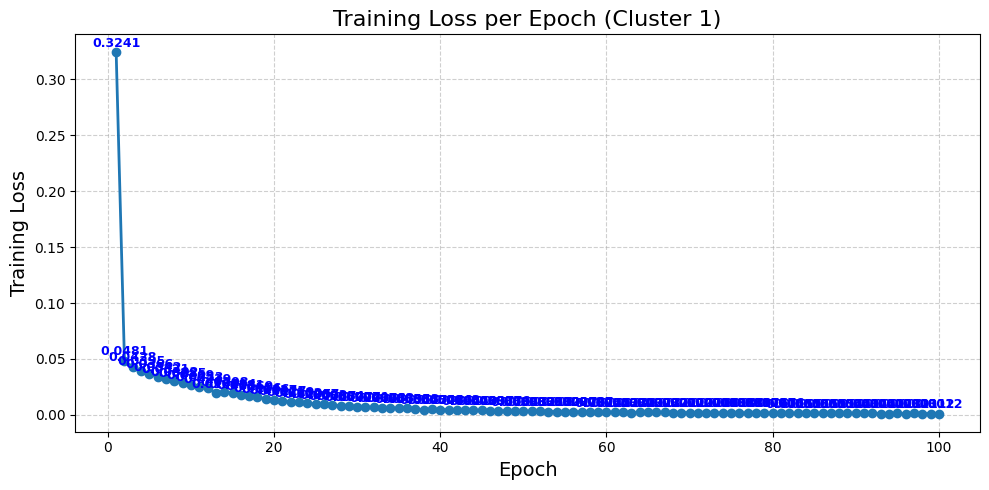

✅ Training complete. Model, loss plot, and architecture saved to:
C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1249_CHOSi\Splitting  with seed 123\models_\model1111


In [22]:
import os
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt
import deepchem as dc

# === Load training cluster 1 data
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1249_CHOSi\Splitting  with  seed 123\clustering_from_trainset\cluster_1.pkl", "rb") as f:
    X_cluster1 = pickle.load(f)

cluster_1_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1249_CHOSi\Splitting  with  seed 123\clustering_from_trainset\cluster_1_indices.npy")
y_cluster1 = train_dataset.y[cluster_1_indices]

# Ensure y is 2D
if len(y_cluster1.shape) == 1:
    y_cluster1 = y_cluster1.reshape(-1, 1)

# === Create DeepChem dataset
train_dataset_1 = dc.data.NumpyDataset(X=np.array(X_cluster1), y=np.array(y_cluster1))

# === Model config
n_tasks = train_dataset_1.y.shape[1]
n_features = train_dataset_1.X.shape[1]
layer_sizes = [1000, 1000, 1000]
dropout_rate = 0.1
num_epochs = 100

model_1 = dc.models.MultitaskClassifier(
    n_tasks=n_tasks,
    n_features=n_features,
    layer_sizes=layer_sizes,
    dropouts=dropout_rate
)

# === Output directory
model_dir = r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1249_CHOSi\Splitting  with seed 123\models_\model1111"
os.makedirs(model_dir, exist_ok=True)

# === Training
losses = []

for epoch in range(num_epochs):
    loss = model_1.fit(train_dataset_1, nb_epoch=1)
    losses.append(loss)
    print(f"Epoch {epoch + 1}/{num_epochs} - Loss: {loss:.6f}")

# === Plot training loss
final_plot = os.path.join(model_dir, "train_loss_plot.png")
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(losses) + 1), losses, marker='o', linewidth=2, markersize=6)
for i, l in enumerate(losses):
    plt.text(i + 1, l + 0.005, f"{l:.4f}", fontsize=9, fontweight='bold', ha='center', color='blue')

plt.title("Training Loss per Epoch (Cluster 1)", fontsize=16)
plt.xlabel("Epoch", fontsize=14)
plt.ylabel("Training Loss", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(final_plot)
plt.show()

# === Save model weights and architecture
model_1.save_checkpoint(model_dir=model_dir)

arch_dict = {
    "n_tasks": n_tasks,
    "n_features": n_features,
    "layer_sizes": layer_sizes,
    "dropout_rate": dropout_rate
}
arch_file = os.path.join(model_dir, "architecture.json")
with open(arch_file, "w") as f:
    json.dump(arch_dict, f, indent=4)

print("✅ Training complete. Model, loss plot, and architecture saved to:")
print(model_dir)



In [23]:
import pickle
import numpy as np
import deepchem as dc

# === Load cluster 1 features from test set
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1249_CHOSi\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_1.pkl", "rb") as f:
    X_test_cluster1 = pickle.load(f)

# === Load corresponding indices
test_cluster_1_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1249_CHOSi\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_1_indices.npy")

# === Extract corresponding labels from the original test set
y_test_cluster1 = test_dataset.y[test_cluster_1_indices]

if len(y_test_cluster1.shape) == 1:
    y_test_cluster1 = y_test_cluster1.reshape(-1, 1)

# === Create DeepChem dataset for test cluster 1
test_dataset_1 = dc.data.NumpyDataset(X=np.array(X_test_cluster1), y=np.array(y_test_cluster1))

# === Predict using the trained model_1
predictions_1 = model_1.predict(test_dataset_1)

# === Inspect prediction shape 
print("✅ Prediction shape:", predictions_1.shape)
print("Example prediction:", predictions_1[0])
evaluate_flat_predictions(predictions_1, test_dataset_1, itos, sf, cutoff=0.5)


✅ Prediction shape: (98, 2590, 2)
Example prediction: [[1.0000000e+00 3.8743188e-08]
 [9.9999917e-01 8.6712305e-07]
 [9.9999940e-01 5.9742473e-07]
 ...
 [9.9999928e-01 7.6218976e-07]
 [9.9999237e-01 7.6081233e-06]
 [4.4824273e-07 9.9999952e-01]]
[0] Pred: CCCCCCC=CC=CC=C=C1OC=CC=C1 | True: C[Si](C)(C)C[Si](C)(C)OC\C=C\C1=CC=CC=C1 | Tanimoto: 0.091
[1] Pred: COC=CC=CO[Si](C)(C)OCCCOCC | True: COC1=CC=C(CO[Si](C)(C)OCCO[SiH1](C)C)C=C1 | Tanimoto: 0.189
[2] Pred: COC1=CC=C(COCCCCO[SiH1](C)C)C=C1 | True: COC1=CC=C(CO[Si](C)(C)OCC(C)C)C=C1 | Tanimoto: 0.478
[3] Pred: C1COC=C[Si]=CCC1CCCCCC=C | True: CC[Si]1(CCCCC1)OCC2=CC=C(OC)C=C2 | Tanimoto: 0.067
[4] Pred: C1OC[Si]=C=CCOC[Si]CC=CC1 | True: COC1=CC=C(C)C=C1CO[SiH1](C2=CC=CC=C2)C3=CC=CC=C3 | Tanimoto: 0.055
[5] Pred: CCC1=[Si](CCC)COC=CC=C1OC | True: CCCC[Si](CCCC)(CCCC)OCC1=CC=C(OC)C=C1 | Tanimoto: 0.106
[6] Pred: CCCCCCCOCCCCCCCCCCC=CC=C | True: CCCCCCCCCC(CCCC)O[Si](C)(C)C1=CC=CC=C1 | Tanimoto: 0.100
[7] Pred: C[Si]O[Si](C)=CCCC1C=CC=C=

Epoch 1/100 - Loss: 0.806825
Epoch 2/100 - Loss: 0.074518
Epoch 3/100 - Loss: 0.050459
Epoch 4/100 - Loss: 0.038002
Epoch 5/100 - Loss: 0.036022
Epoch 6/100 - Loss: 0.034356
Epoch 7/100 - Loss: 0.032424
Epoch 8/100 - Loss: 0.031155
Epoch 9/100 - Loss: 0.029768
Epoch 10/100 - Loss: 0.028692
Epoch 11/100 - Loss: 0.027410
Epoch 12/100 - Loss: 0.026458
Epoch 13/100 - Loss: 0.025039
Epoch 14/100 - Loss: 0.024050
Epoch 15/100 - Loss: 0.022922
Epoch 16/100 - Loss: 0.021763
Epoch 17/100 - Loss: 0.020549
Epoch 18/100 - Loss: 0.019541
Epoch 19/100 - Loss: 0.018511
Epoch 20/100 - Loss: 0.017604
Epoch 21/100 - Loss: 0.016618
Epoch 22/100 - Loss: 0.015621
Epoch 23/100 - Loss: 0.014619
Epoch 24/100 - Loss: 0.013665
Epoch 25/100 - Loss: 0.012789
Epoch 26/100 - Loss: 0.012081
Epoch 27/100 - Loss: 0.011163
Epoch 28/100 - Loss: 0.010634
Epoch 29/100 - Loss: 0.010083
Epoch 30/100 - Loss: 0.009228
Epoch 31/100 - Loss: 0.008728
Epoch 32/100 - Loss: 0.008023
Epoch 33/100 - Loss: 0.007722
Epoch 34/100 - Loss

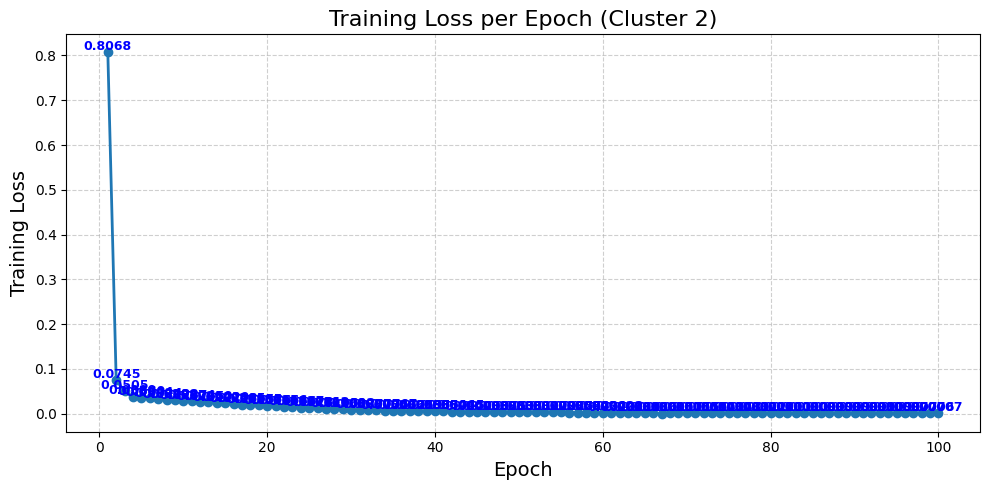

✅ Training complete. Model, loss plot, and architecture saved to:
C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1249_CHOSi\Splitting  with seed 123\models_\model2222


In [24]:
import os
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt
import deepchem as dc

# === Load training cluster 2 data
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1249_CHOSi\Splitting  with  seed 123\clustering_from_trainset\cluster_2.pkl", "rb") as f:
    X_cluster2 = pickle.load(f)

cluster_2_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1249_CHOSi\Splitting  with  seed 123\clustering_from_trainset\cluster_2_indices.npy")
y_cluster2 = train_dataset.y[cluster_2_indices]

if len(y_cluster2.shape) == 1:
    y_cluster2 = y_cluster2.reshape(-1, 1)

# === Create DeepChem dataset
train_dataset_2 = dc.data.NumpyDataset(X=np.array(X_cluster2), y=np.array(y_cluster2))

# === Model config
n_tasks = train_dataset_2.y.shape[1]
n_features = train_dataset_2.X.shape[1]
layer_sizes = [1000, 1000, 1000]
dropout_rate = 0.1
num_epochs = 100

model_2 = dc.models.MultitaskClassifier(
    n_tasks=n_tasks,
    n_features=n_features,
    layer_sizes=layer_sizes,
    dropouts=dropout_rate
)

# === Output directory
model_dir = r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1249_CHOSi\Splitting  with seed 123\models_\model2222"
os.makedirs(model_dir, exist_ok=True)

# === Training
losses = []

for epoch in range(num_epochs):
    loss = model_2.fit(train_dataset_2, nb_epoch=1)
    losses.append(loss)
    print(f"Epoch {epoch + 1}/{num_epochs} - Loss: {loss:.6f}")

# === Plot training loss
final_plot = os.path.join(model_dir, "train_loss_plot.png")
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(losses) + 1), losses, marker='o', linewidth=2, markersize=6)
for i, l in enumerate(losses):
    plt.text(i + 1, l + 0.005, f"{l:.4f}", fontsize=9, fontweight='bold', ha='center', color='blue')

plt.title("Training Loss per Epoch (Cluster 2)", fontsize=16)
plt.xlabel("Epoch", fontsize=14)
plt.ylabel("Training Loss", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(final_plot)
plt.show()

# === Save model weights and architecture
model_2.save_checkpoint(model_dir=model_dir)

arch_dict = {
    "n_tasks": n_tasks,
    "n_features": n_features,
    "layer_sizes": layer_sizes,
    "dropout_rate": dropout_rate
}
arch_file = os.path.join(model_dir, "architecture.json")
with open(arch_file, "w") as f:
    json.dump(arch_dict, f, indent=4)

print("✅ Training complete. Model, loss plot, and architecture saved to:")
print(model_dir)


In [25]:
# === Load cluster 2 features from test set
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1249_CHOSi\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_2.pkl", "rb") as f:
    X_test_cluster2 = pickle.load(f)

# === Load corresponding indices
test_cluster_2_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_1249_CHOSi\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_2_indices.npy")

# === Extract corresponding labels from the original test set
y_test_cluster2 = test_dataset.y[test_cluster_2_indices]

if len(y_test_cluster2.shape) == 1:
    y_test_cluster2 = y_test_cluster2.reshape(-1, 1)

# === Create DeepChem dataset for test cluster 2
test_dataset_2 = dc.data.NumpyDataset(X=np.array(X_test_cluster2), y=np.array(y_test_cluster2))

# === Predict using the trained model_2
predictions_2 = model_2.predict(test_dataset_2)

# === Inspect prediction shape 
print("✅ Prediction shape:", predictions_2.shape)
print("Example prediction:", predictions_2[0])

evaluate_flat_predictions(predictions_2, test_dataset_2, itos, sf, cutoff=0.5)


✅ Prediction shape: (37, 2590, 2)
Example prediction: [[1.0000000e+00 5.2073638e-08]
 [1.0000000e+00 9.9268562e-12]
 [1.0000000e+00 6.1873358e-14]
 ...
 [1.0000000e+00 1.4371047e-12]
 [1.0000000e+00 5.9216271e-13]
 [1.6413473e-08 1.0000000e+00]]
[0] Pred: C[Si](C)CCCCCOCCCCC=CC | True: COCCC(CCO[Si](C)(C)C)C1=CC=CC=C1 | Tanimoto: 0.138
[1] Pred: COC(=O)C1CC(CC1C2=CC=CC=C2)=C[Si](C)(C)C | True: COC(=O)C1CC(CC1C2=CC=CC=C2)=C[Si](C)(C)C | Tanimoto: 1.000
[2] Pred: CC(C)CC(=O)OCC1CCC=C=C1CC=C | True: CC(C)[Si](OC(C(C)=C)C1=CC=C(C)C=C1CO)(C(C)C)C(C)C | Tanimoto: 0.109
[3] Pred: COC=CC=C=O | True: C[Si](C)(C)C1=CC=CC(OCCOCCOC2=CC=CC=C2OCCOCCOC3=CC=CC(=C3)[Si](C)(C)C)=C1 | Tanimoto: 0.027
[4] Pred: COC1=CC=CC(CCC(=O)O[Si](C)(C)C)=C1 | True: COC1=CC=CC=C1C(C)C(=O)O[Si](C)(C)C | Tanimoto: 0.393
[5] Pred: CC(C)(OCCC1=CCC[CH0]1[CH0]C2=CC=CC=C2)C=C=C | True: CC(C)(COC1=CC=CC=C1)O[Si](C)(C)C | Tanimoto: 0.104
[6] Pred: C[Si](C)(C)OCC=O | True: C[Si](C)(C)[Si](C)(C)OCCC1=CC=CC=C1 | Tanimoto: 0.132
[